<np>

# REGRESIÓN LINEAL

<np>

# Introducción

In [2]:
# Regresión lineal: normal condicional para regresión. EN REGRESION LINEAL PREDECIMOS NUMEROS, VALORES CONCRETOS. EN REGRESION LOGISTICA, PREDECIMOS PROBABILIDADES DE PERTENECER A UNA CLASE
# Con scikit-learn: LinearRegression

# fit_interceptbool = True      > añade w0
# copy_Xbool = True             > copia el dataset de entrenamiento

import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])  # Muestras 
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3 # Construimos un polinomio que relacione las distintas caracteriticas
reg = LinearRegression().fit(X, y)  # entrenamos el modelo 
print(reg.score(X, y))  # devuelve R² , que mide que procengaje de la variabilidad de y explica el modelo
print(reg.coef_)
print(reg.intercept_)
print(reg.predict(np.array([[3, 5]])))  # Predecimos para un caso concreto el valor de y

1.0
[1. 2.]
3.0000000000000018
[16.]


<np>

# Aplicación a auto-mpg

In [3]:
# auto-mpg es un dataset usado para aprender regresión lineal y analisis de datos. Contiene info de coches
# 

import numpy as np
import datasets

ds = datasets.load_dataset("scikit-learn/auto-mpg")
ds

/home/adria/Documentos/GitHub/University/3rd_Year/PER/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name'],
        num_rows: 398
    })
})

In [4]:
import pandas as pd

df = ds["train"].to_pandas()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB


In [5]:
# Preproceso : tras examinar variables en el DataSet Viewer

df.drop(df[df.horsepower == "?"].index, inplace=True)
df = df.astype({"horsepower": np.int64})
df["origin"] = df["origin"].map({1: "USA", 2: "Europe", 3: "Japan"})
df = df.astype({"origin": "category"})
df.drop("car name", axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    int64   
 4   weight        392 non-null    int64   
 5   acceleration  392 non-null    float64 
 6   model year    392 non-null    int64   
 7   origin        392 non-null    category
dtypes: category(1), float64(3), int64(4)
memory usage: 24.9 KB


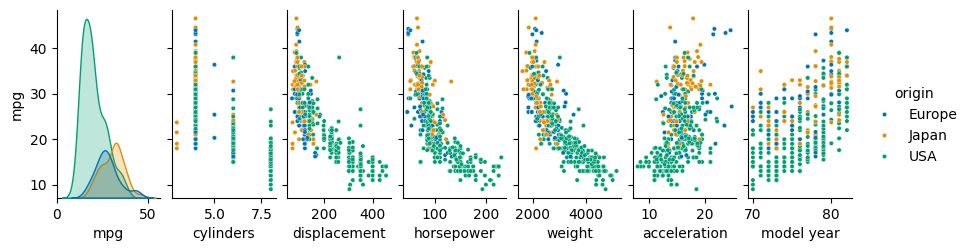

In [6]:
# Inspección visual: vamos a ver como cambia el consumo con respeccto a atodas las demás variables del DataFrame spearando por el origen del coche
import seaborn as sns

# sns.pairplot: crea graficos de dispersion para ver la relacion entre variables numericas

sns.pairplot(
    df,
    y_vars="mpg",       # En lugar de hacer todas las comparativas posibles, aqui hacemos mpg vs cada otra variable
    hue="origin",       # Colorea los puntos según el origen del coche
    aspect=0.5,            # Relacion ancho/alto
    palette="colorblind",   # Paleta de colores 
    plot_kws=dict(marker="o", s=10),    # Parametros del scatter plot interno
)

In [7]:
# Diseño experimental
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# One-hot encoding de la columna
df = pd.concat([df, pd.get_dummies(df.origin, prefix="", prefix_sep="")], axis=1) # get_dummies convierte origin en una variable one-hot (100 -> USA, 010 -> Europe, 001 -> Japan)
df.drop("origin", axis=1, inplace=True)

# Separamos entre X featurs e y target
y = df.pop("mpg")
X = df
# Division entre entrenamiento(0.75) y test(0.25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42   # random_state: fijo, asegura division siempre la misma
)
# Estandarizacion. Convierte cada  columna a media = 0 y desviacion = 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit_transform()
X_test = scaler.transform(X_test)       # solo transform()

In [8]:
# REGRESIÓN LINEAL SIN INGENIERIA DE CARACTERISTICAS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

linreg = LinearRegression().fit(X_train, y_train) # entrenamos el modelo con los datos procesados
y_train_pred = linreg.predict(X_train)      # predecimos las ys de los datos de entrenamiento...
y_test_pred = linreg.predict(X_test)        #... y de los datos test
r2_train = r2_score(y_train, y_train_pred)  # Comprobamos como de diferentes son
r2_test = r2_score(y_test, y_test_pred)

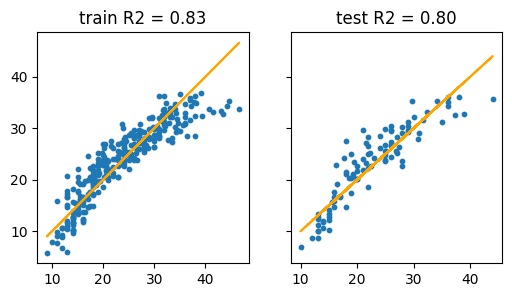

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey="all")
ax = axs[0]
ax.set_title(f"train R2 = {r2_train:.2f}")  # R2 train = puntuacion obtenida por la prediccion
ax.scatter(y_train, y_train_pred, s=10)
ax.plot(y_train, y_train, color="orange")
ax = axs[1]
ax.set_title(f"test R2 = {r2_test:.2f}")    # R2 test = puntuacion obtenida por el test
ax.scatter(y_test, y_test_pred, s=10)
ax.plot(y_test, y_test, color="orange")

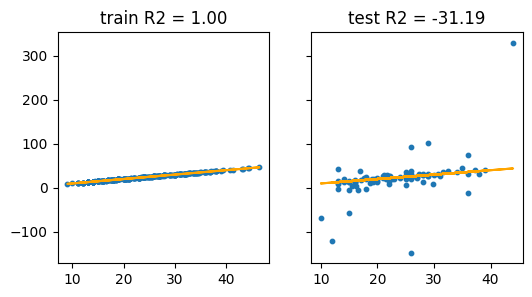

In [12]:
# CON INGENIERIA DE CARACTERÍSTICAS
from sklearn.preprocessing import PolynomialFeatures
# Definimos la transformacion a aplicar a los datos
poly = PolynomialFeatures(2)  # degree = 2
X_train = poly.fit_transform(X_train)   # fit entiende la estructura de los datos. transform realiza la conversion
X_test = poly.transform(X_test)
# entrenamos el modelo de regresion lineal
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
# calculamos la puntuacion
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Representacion
ig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey="all")
ax = axs[0]
ax.set_title(f"train R2 = {r2_train:.2f}")
ax.scatter(y_train, y_train_pred, s=10)
ax.plot(y_train, y_train, color="orange")
ax = axs[1]
ax.set_title(f"test R2 = {r2_test:.2f}")
ax.scatter(y_test, y_test_pred, s=10)
ax.plot(y_test, y_test, color="orange")

<np>

# EJERCICIO

In [ ]:
# fish database


import numpy as np
import datasets
import pandas as pd

df = datasets.load_dataset("scikit-learn/Fish")["train"].to_pandas()
df.info()

Generating train split: 100%|██████████| 159/159 [00:00<00:00, 61641.03 examples/s]

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = df.astype({"Species": "category"})
df = pd.concat([df, pd.get_dummies(df.Species, prefix="", prefix_sep="")], axis=1)
df.drop("Species", axis=1, inplace=True)
y = df.pop("Weight")
X = df
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
sin_r2_train = r2_score(y_train, y_train_pred)
sin_r2_test = r2_score(y_test, y_test_pred)

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
con_r2_train = r2_score(y_train, y_train_pred)
con_r2_test = r2_score(y_test, y_test_pred)
print(
    f"R2: sin {sin_r2_test:.2f} con {con_r2_test:.2f} (train: sin {sin_r2_train:.2f} con {con_r2_train:.2f})"
)

R2: sin 0.95 con 0.96 (train: sin 0.93 con 0.99)


In [ ]:
# tips database


import numpy as np
import datasets
import pandas as pd

df = datasets.load_dataset("scikit-learn/tips")["train"].to_pandas()
df.info()

Repo card metadata block was not found. Setting CardData to empty.
Generating train split: 100%|██████████| 244/244 [00:00<00:00, 104068.56 examples/s]

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


In [19]:
df.sex = df.sex.map({"Male": 0, "Female": 1}).astype("bool")
df.smoker = df.smoker.map({"No": 0, "Yes": 1}).astype("bool")
df = df.astype({"day": "category"})
df = pd.concat([df, pd.get_dummies(df.day, prefix="", prefix_sep="")], axis=1)
df.drop("day", axis=1, inplace=True)
df.time = df.time.map({"Dinner": 0, "Lunch": 1}).astype("bool")
y = df.pop("total_bill")
X = df

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
# creamos refernecia al modelo regeresion lineal. SIN INGENIERIA DE CARACTERISTICAS
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
sin_r2_train = r2_score(y_train, y_train_pred)
sin_r2_test = r2_score(y_test, y_test_pred)

# CON INGENIERIA DE CARACTERISTICAS
X_train = np.c_[(np.ones((X_train.shape[0], 1)), X_train, np.square(X_train))]
X_test = np.c_[(np.ones((X_test.shape[0], 1)), X_test, np.square(X_test))]
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
con_r2_train = r2_score(y_train, y_train_pred)
con_r2_test = r2_score(y_test, y_test_pred)

print(f'R2: sin {sin_r2_test:.2f} con {con_r2_test:.2f} (train: sin {sin_r2_train:.2f} con {con_r2_train:.2f})')

R2: sin 0.55 con 0.51 (train: sin 0.58 con 0.59)
